# [Final project](https://www.edu.goit.global/learn/25315460/26519706/26524804/training?blockId=28528871)
- Kaggle competition: [Deep Learning for Computer Vision and NLP 2025-05](https://www.kaggle.com/competitions/deep-learning-for-computer-vision-and-nlp-2025-05/leaderboard)
- Dataset: [PetFinder.my Adoption Prediction](https://www.kaggle.com/competitions/petfinder-adoption-prediction/data)

In [1]:
import os
import gc

from pathlib import Path
import subprocess
import json

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
import torch
from torch.utils.data import DataLoader, Dataset
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

import optuna

2025-05-31 23:38:04.619442: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-31 23:38:04.627575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748723884.636569  335340 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748723884.639630  335340 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748723884.646947  335340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def check_gpu_availability():
    """Check if GPU is available for different ML libraries."""
    gpu_info = {"lightgbm": False, "catboost": False, "xgboost": False}

    # Check NVIDIA GPU
    try:
        result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        if result.returncode == 0:
            print("✓ NVIDIA GPU detected")
            gpu_available = True
        else:
            print("✗ No NVIDIA GPU found")
            gpu_available = False
    except FileNotFoundError:
        print("✗ nvidia-smi not found - no NVIDIA GPU")
        gpu_available = False

    if gpu_available:
        # Check LightGBM GPU support
        try:
            import lightgbm as lgb

            test_params = {"device": "gpu", "objective": "regression", "verbose": -1}
            gpu_info["lightgbm"] = True
            print("✓ LightGBM GPU support available")
        except Exception as e:
            print(f"✗ LightGBM GPU support not available: {e}")
            gpu_info["lightgbm"] = False

        # Check CatBoost GPU support
        try:
            from catboost import CatBoostRegressor

            gpu_info["catboost"] = True
            print("✓ CatBoost GPU support available")
        except Exception as e:
            print(f"✗ CatBoost GPU support not available: {e}")
            gpu_info["catboost"] = False

        # Check XGBoost GPU support
        try:
            import xgboost as xgb

            gpu_info["xgboost"] = True
            print("✓ XGBoost GPU support available")
        except Exception as e:
            print(f"✗ XGBoost GPU support not available: {e}")
            gpu_info["xgboost"] = False

    return gpu_info


GPU_INFO = check_gpu_availability()
print(f"\nGPU Support Summary: {GPU_INFO}")

# Configure GPU acceleration settings
print("\n" + "=" * 50)
print("GPU ACCELERATION CONFIGURATION")
print("=" * 50)

if any(GPU_INFO.values()):
    print("GPU acceleration will be used for supported models:")
    for model, supported in GPU_INFO.items():
        status = "✓" if supported else "✗"
        print(f"  {status} {model.upper()}: {'Enabled' if supported else 'CPU only'}")
else:
    print("No GPU acceleration available - using CPU for all models")

print("=" * 50)


def clean_gpu_resources():
    """Clear GPU resources and perform garbage collection."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print(
            f"GPU memory cleared. Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f}GB"
        )

    gc.collect()
    print("Garbage collection completed")

✓ NVIDIA GPU detected
✓ LightGBM GPU support available
✓ CatBoost GPU support available
✓ XGBoost GPU support available

GPU Support Summary: {'lightgbm': True, 'catboost': True, 'xgboost': True}

GPU ACCELERATION CONFIGURATION
GPU acceleration will be used for supported models:
  ✓ LIGHTGBM: Enabled
  ✓ CATBOOST: Enabled
  ✓ XGBOOST: Enabled


## Configs

In [3]:
DATA = Path("~/Projects/DataSets/GoIT/petfinder-final").expanduser()
TRAIN_CSV = DATA / "train.csv"
TEST_CSV = DATA / "test.csv"
IMG_TRAIN_DIR = DATA / "images/train"
IMG_TEST_DIR = DATA / "images/test"
OUTPUTS = DATA / "outputs"
HYPERPARAMS_FILE = OUTPUTS / "lgbm_best_params.json"
FORCE_REOPTIMIZE = True  # Set to True to force re-optimization
N_TRIALS = 25  # Number of Optuna trials
OUTPUTS.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Utils: QWK & Plots

In [4]:
# https://github.com/benhamner/Metrics
# https://www.kaggle.com/competitions/petfinder-adoption-prediction/discussion/76106


def confusion_matrix(rater_a, rater_b, min_rating=None, max_rating=None):
    """Returns the confusion matrix between rater's ratings."""
    assert len(rater_a) == len(rater_b)
    if min_rating is None:
        min_rating = min(rater_a + rater_b)
    if max_rating is None:
        max_rating = max(rater_a + rater_b)
    num_ratings = int(max_rating - min_rating + 1)
    conf_mat = [[0 for i in range(num_ratings)] for j in range(num_ratings)]
    for a, b in zip(rater_a, rater_b):
        conf_mat[a - min_rating][b - min_rating] += 1
    return conf_mat


def histogram(ratings, min_rating=None, max_rating=None):
    """Returns the counts of each type of rating that a rater made."""
    if min_rating is None:
        min_rating = min(ratings)
    if max_rating is None:
        max_rating = max(ratings)
    num_ratings = int(max_rating - min_rating + 1)
    hist_ratings = [0 for x in range(num_ratings)]
    for r in ratings:
        hist_ratings[r - min_rating] += 1
    return hist_ratings


def quadratic_weighted_kappa(y, y_pred):
    """
    Calculates the quadratic weighted kappa
    axquadratic_weighted_kappa calculates the quadratic weighted kappa
    value, which is a measure of inter-rater agreement between two raters
    that provide discrete numeric ratings.  Potential values range from -1
    (representing complete disagreement) to 1 (representing complete
    agreement).  A kappa value of 0 is expected if all agreement is due to
    chance.
    quadratic_weighted_kappa(rater_a, rater_b), where rater_a and rater_b
    each correspond to a list of integer ratings.  These lists must have the
    same length.
    The ratings should be integers, and it is assumed that they contain
    the complete range of possible ratings.
    quadratic_weighted_kappa(X, min_rating, max_rating), where min_rating
    is the minimum possible rating, and max_rating is the maximum possible
    rating
    """
    rater_a = y
    rater_b = y_pred
    min_rating = None
    max_rating = None
    rater_a = np.array(rater_a, dtype=int)
    rater_b = np.array(rater_b, dtype=int)
    assert len(rater_a) == len(rater_b)
    if min_rating is None:
        min_rating = min(min(rater_a), min(rater_b))
    if max_rating is None:
        max_rating = max(max(rater_a), max(rater_b))
    conf_mat = confusion_matrix(rater_a, rater_b, min_rating, max_rating)
    num_ratings = len(conf_mat)
    num_scored_items = float(len(rater_a))

    hist_rater_a = histogram(rater_a, min_rating, max_rating)
    hist_rater_b = histogram(rater_b, min_rating, max_rating)

    numerator = 0.0
    denominator = 0.0

    for i in range(num_ratings):
        for j in range(num_ratings):
            expected_count = hist_rater_a[i] * hist_rater_b[j] / num_scored_items
            d = pow(i - j, 2.0) / pow(num_ratings - 1, 2.0)
            numerator += d * conf_mat[i][j] / num_scored_items
            denominator += d * expected_count / num_scored_items

    return 1.0 - numerator / denominator


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", figsize=(8, 6)):
    """Plot a confusion matrix using seaborn heatmap."""
    min_rating = min(min(y_true), min(y_pred))
    max_rating = max(max(y_true), max(y_pred))

    conf_mat = confusion_matrix(y_true, y_pred, min_rating, max_rating)
    conf_mat = np.array(conf_mat)

    labels = [str(i + min_rating) for i in range(len(conf_mat))]

    plt.figure(figsize=figsize)
    sns.heatmap(
        conf_mat,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Count"},
    )

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted AdoptionSpeed", fontsize=12, fontweight="bold")
    plt.ylabel("True AdoptionSpeed", fontsize=12, fontweight="bold")

    # Add QWK score to the plot
    qwk = quadratic_weighted_kappa(y_true, y_pred)
    plt.text(
        0.02,
        0.98,
        f"QWK: {qwk:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.8),
        verticalalignment="top",
    )

    plt.tight_layout()
    plt.show()

    return conf_mat


def plot_detailed_results(y_true, y_pred, title="Results"):
    """Plot comprehensive visual evaluation results including confusion matrix and distributions."""
    qwk = quadratic_weighted_kappa(y_true, y_pred)

    min_rating = min(min(y_true), min(y_pred))
    max_rating = max(max(y_true), max(y_pred))

    conf_mat = confusion_matrix(y_true, y_pred, min_rating, max_rating)
    hist_true = histogram(y_true, min_rating, max_rating)
    hist_pred = histogram(y_pred, min_rating, max_rating)

    fig = plt.figure(figsize=(16, 12))

    # Confusion Matrix
    plt.subplot(2, 3, 1)
    conf_mat_np = np.array(conf_mat)
    labels = [str(i + min_rating) for i in range(len(conf_mat))]
    sns.heatmap(
        conf_mat_np,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Count"},
    )
    plt.title(f"Confusion Matrix\nQWK: {qwk:.4f}", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")

    # Class Distribution Comparison
    plt.subplot(2, 3, 2)
    x_pos = np.arange(len(hist_true))
    width = 0.35
    plt.bar(
        x_pos - width / 2, hist_true, width, label="True", alpha=0.8, color="skyblue"
    )
    plt.bar(
        x_pos + width / 2,
        hist_pred,
        width,
        label="Predicted",
        alpha=0.8,
        color="orange",
    )
    plt.xlabel("AdoptionSpeed Class", fontweight="bold")
    plt.ylabel("Count", fontweight="bold")
    plt.title("Class Distribution Comparison", fontsize=12, fontweight="bold")
    plt.xticks(x_pos, [str(i + min_rating) for i in range(len(hist_true))])
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    # Normalized Confusion Matrix
    plt.subplot(2, 3, 3)
    conf_mat_norm = conf_mat_np.astype("float") / conf_mat_np.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        conf_mat_norm,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Proportion"},
    )
    plt.title("Normalized Confusion Matrix\n(Row-wise)", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")

    # Error Analysis
    plt.subplot(2, 3, 4)
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    errors = y_pred_arr - y_true_arr

    error_counts = np.bincount(errors + max_rating, minlength=2 * max_rating + 1)
    error_labels = list(range(-max_rating, max_rating + 1))

    colors = ["red" if x < 0 else "green" if x > 0 else "gray" for x in error_labels]
    plt.bar(error_labels, error_counts, color=colors, alpha=0.7)
    plt.xlabel("Prediction Error (Pred - True)", fontweight="bold")
    plt.ylabel("Count", fontweight="bold")
    plt.title("Prediction Error Distribution", fontsize=12, fontweight="bold")
    plt.axvline(x=0, color="black", linestyle="--", alpha=0.8)
    plt.grid(axis="y", alpha=0.3)

    # Accuracy by Class
    plt.subplot(2, 3, 5)
    class_accuracies = []
    for i in range(len(conf_mat)):
        if sum(conf_mat[i]) > 0:
            accuracy = conf_mat[i][i] / sum(conf_mat[i])
            class_accuracies.append(accuracy)
        else:
            class_accuracies.append(0)

    class_names = [str(i + min_rating) for i in range(len(class_accuracies))]
    colors = plt.cm.RdYlGn([acc for acc in class_accuracies])
    bars = plt.bar(class_names, class_accuracies, color=colors, alpha=0.8)
    plt.xlabel("AdoptionSpeed Class", fontweight="bold")
    plt.ylabel("Accuracy", fontweight="bold")
    plt.title("Per-Class Accuracy", fontsize=12, fontweight="bold")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    # Add value labels
    for bar, acc in zip(bars, class_accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc:.2f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # Prediction Scatter Plot
    plt.subplot(2, 3, 6)
    plt.scatter(y_true, y_pred, alpha=0.6, s=30)
    plt.plot(
        [min_rating, max_rating],
        [min_rating, max_rating],
        "r--",
        alpha=0.8,
        linewidth=2,
    )
    plt.xlabel("True AdoptionSpeed", fontweight="bold")
    plt.ylabel("Predicted AdoptionSpeed", fontweight="bold")
    plt.title("True vs Predicted Scatter", fontsize=12, fontweight="bold")
    plt.grid(True, alpha=0.3)

    # Add correlation coefficient
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    plt.text(
        0.05,
        0.95,
        f"Correlation: {correlation:.3f}",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
        verticalalignment="top",
    )

    # Title
    fig.suptitle(
        f"{title} - Comprehensive Evaluation (QWK: {qwk:.4f})",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

    return {
        "qwk": qwk,
        "confusion_matrix": conf_mat_np,
        "class_accuracies": class_accuracies,
        "correlation": correlation,
    }


def plot_test_predictions_distribution(
    predictions, title="Test Predictions Distribution"
):
    """Plot the distribution of test predictions with beautiful visualization."""
    pred_counts = np.bincount(predictions.astype(int))
    classes = np.arange(len(pred_counts))

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot
    colors = plt.cm.viridis(np.linspace(0, 1, len(pred_counts)))
    bars = ax1.bar(classes, pred_counts, color=colors, alpha=0.8, edgecolor="black")
    ax1.set_xlabel("AdoptionSpeed Class", fontweight="bold", fontsize=12)
    ax1.set_ylabel("Count", fontweight="bold", fontsize=12)
    ax1.set_title("Test Predictions Count by Class", fontweight="bold", fontsize=14)
    ax1.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar, count in zip(bars, pred_counts):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(pred_counts) * 0.01,
            str(count),
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # Pie chart
    ax2.pie(
        pred_counts,
        labels=[f"Class {i}" for i in classes],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
    )
    ax2.set_title("Test Predictions Distribution", fontweight="bold", fontsize=14)

    # Title
    fig.suptitle(
        f"{title} (Total: {len(predictions)} samples)", fontsize=16, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n=== {title} Summary ===")
    print(f"Total samples: {len(predictions)}")
    for i, count in enumerate(pred_counts):
        percentage = (count / len(predictions)) * 100
        print(f"Class {i}: {count:>4} ({percentage:>5.1f}%)")


def save_best_params(params, filename=HYPERPARAMS_FILE):
    """Save best hyperparameters to JSON file."""
    try:
        filename.parent.mkdir(exist_ok=True)

        with open(filename, "w") as f:
            json.dump(params, f, indent=4)
        print(f"Best hyperparameters saved to {filename}")
        return True
    except Exception as e:
        print(f"Error saving hyperparameters: {e}")
        return False


def load_best_params(filename=HYPERPARAMS_FILE):
    """Load best hyperparameters from JSON file."""
    try:
        if not os.path.exists(filename):
            print(f"No saved hyperparameters found at {filename}")
            return None

        with open(filename, "r") as f:
            params = json.load(f)
        print(f"Loaded hyperparameters from {filename}")
        print(f"Loaded params: {params}")
        return params
    except Exception as e:
        print(f"Error loading hyperparameters: {e}")
        return None

## EDA

### Data Cleaning, Sentiment,  Metadata

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
display(train_df.head())

,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2
3,693a90fda,Neil is a healthy and active ~2-month-old fema...,2
4,9d08c85ef,Gray kitten available for adoption in sungai p...,2


In [6]:
display(train_df.describe().T)
display(test_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
AdoptionSpeed,6431.0,2.683719,1.118951,1.0,2.0,3.0,4.0,4.0


,count,unique,top,freq
PetID,1891,1891,6697a7f62,1
Description,1890,1836,For Adoption,21


In [7]:
display(train_df.info())
display(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6431 entries, 0 to 6430
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PetID          6431 non-null   object
 1   Description    6426 non-null   object
 2   AdoptionSpeed  6431 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 150.9+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891 entries, 0 to 1890
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PetID        1891 non-null   object
 1   Description  1890 non-null   object
dtypes: object(2)
memory usage: 29.7+ KB


None

In [8]:
display(train_df.isnull().sum())
display(test_df.isnull().sum())

PetID            0
Description      5
AdoptionSpeed    0
dtype: int64

PetID          0
Description    1
dtype: int64

### Handling Empty Descriptions

In [9]:
def clean_and_save_data(fill_empty_desc=False, empty_desc_value="no description"):
    """
    Clean, and check for image file existence. 
    Saves cleaned data with image existence flags as .pkl
    """
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)

    train_empty = train_df["Description"].isna().sum()
    test_empty = test_df["Description"].isna().sum()
    print(f"Empty descriptions before processing:")
    print(f"TRAIN: {train_empty} out of {len(train_df)} ({train_empty/len(train_df)*100:.2f}%)")
    print(f"TEST: {test_empty} out of {len(test_df)} ({test_empty/len(test_df)*100:.2f}%)")

    # Clean text data
    for df in [train_df, test_df]:
        if fill_empty_desc:
            df["Description"] = df["Description"].fillna(empty_desc_value).str.lower().str.strip()
            print(f"\nFilled empty descriptions with: '{empty_desc_value}'")
        else:
            df["Description"] = df["Description"].fillna("").str.lower().str.strip()

    # Check image existence
    for df, img_dir, split in [
        (train_df, IMG_TRAIN_DIR, "train"),
        (test_df, IMG_TEST_DIR, "test")
    ]:
        df['has_image'] = False

        for idx, pet_id in tqdm(enumerate(df['PetID']), desc=f"Checking image files ({split})", total=len(df)):
            image_files = list(img_dir.glob(f"{pet_id}*.jpg"))
            df.loc[idx, 'has_image'] = len(image_files) > 0

        # Show statistics after checking
        img_count = df['has_image'].sum()
        img_missing = (~df['has_image']).sum()
        print(f"\n[{split.upper()}] Image statistics:")
        print(f"Total records: {len(df)}")
        print(f"Records with images: {img_count} ({img_count/len(df)*100:.2f}%)")
        print(f"Records without images: {img_missing} ({img_missing/len(df)*100:.2f}%)")

    if fill_empty_desc:
        mask_train = (train_df["has_image"])
        mask_test = (test_df["has_image"])
        print("\nKeeping records with filled descriptions")
        train_filtered = train_df.reset_index(drop=True)
        test_filtered = test_df.reset_index(drop=True)

    else:
        mask_train = (train_df["Description"] != "") & (train_df["has_image"])
        mask_test = (test_df["Description"] != "") & (test_df["has_image"])
        print("\nFiltering out empty descriptions")

        train_filtered = train_df[mask_train].reset_index(drop=True)
        test_filtered = test_df[mask_test].reset_index(drop=True)

    print(f"\nFiltering statistics:")
    print(f"TRAIN - Original: {len(train_df)}, After filtering: {len(train_filtered)} ({len(train_filtered)/len(train_df)*100:.2f}%)")
    print(f"TEST - Original: {len(test_df)}, After filtering: {len(test_filtered)} ({len(test_filtered)/len(test_df)*100:.2f}%)")

    # suffix = "_with_placeholders" if fill_empty_desc else "_clean"
    suffix = "_clean"

    train_filtered.to_pickle(OUTPUTS / f"train{suffix}.pkl")
    test_filtered.to_pickle(OUTPUTS / f"test{suffix}.pkl")

    return train_filtered, test_filtered

In [10]:
if not ((OUTPUTS / "train_clean.pkl").exists() and (OUTPUTS / "test_clean.pkl").exists()):
    train_df, test_df = clean_and_save_data(fill_empty_desc=True)
else:
    print("Using existing cleaned data files.")
    train_df = pd.read_pickle(OUTPUTS / "train_clean.pkl")
    test_df = pd.read_pickle(OUTPUTS / "test_clean.pkl")

Using existing cleaned data files.


### Remove stopwords

In [11]:
def remove_stopwords(text, stopwords_set=STOPWORDS):
    """Remove stopwords from the given text."""
    return " ".join(
        [word for word in text.split() if word.lower() not in stopwords_set]
    )


def add_nlp_features(df, text_col="Description"):
    """Add various NLP features to the DataFrame based on the specified text column."""
    df[text_col] = df[text_col].fillna("").astype(str)
    df["desc_length"] = df[text_col].apply(len)
    df["desc_word_count"] = df[text_col].apply(lambda x: len(x.split()))
    df["desc_unique_words"] = df[text_col].apply(lambda x: len(set(x.split())))
    df["desc_words_vs_unique"] = df["desc_unique_words"] / (
        df["desc_word_count"] + 1e-5
    )
    df["desc_capitals"] = df[text_col].apply(lambda x: sum(1 for c in x if c.isupper()))
    df["desc_caps_vs_length"] = df["desc_capitals"] / (df["desc_length"] + 1e-5)
    df["desc_num_exclamation_marks"] = df[text_col].apply(lambda x: x.count("!"))
    df["desc_num_question_marks"] = df[text_col].apply(lambda x: x.count("?"))
    df["desc_num_punctuation"] = df[text_col].apply(
        lambda x: sum(x.count(w) for w in ".,;:")
    )
    df["desc_num_symbols"] = df[text_col].apply(
        lambda x: sum(x.count(w) for w in "*&$%")
    )
    smileys = [":-)", ":)", ";-)", ";)", ":D", "XD"]
    sad_smileys = [":-(", ":(", ";-(", ";("]
    df["desc_num_smilies"] = df[text_col].apply(
        lambda x: sum(x.count(s) for s in smileys)
    )
    df["desc_num_sad"] = df[text_col].apply(
        lambda x: sum(x.count(s) for s in sad_smileys)
    )

    return df


def add_stopword_stats(df, text_col="Description"):
    """Add stopword statistics to the DataFrame based on the specified text column."""
    df[text_col + "_no_stopwords"] = df[text_col].apply(remove_stopwords)
    df[text_col + "_stopword_count"] = df[text_col].apply(
        lambda x: sum(1 for word in x.split() if word.lower() in STOPWORDS)
    )
    df[text_col + "_stopword_ratio"] = df[text_col + "_stopword_count"] / (
        df[text_col].apply(lambda x: len(x.split())) + 1e-5
    )
    return df

In [12]:
train_df = pd.read_pickle(OUTPUTS / "train_clean.pkl")
test_df = pd.read_pickle(OUTPUTS / "test_clean.pkl")

display(train_df["Description"].head(2))
display(test_df["Description"].head(2))

0    mayleen and flo are two lovely adorable sister...
1    a total of 5 beautiful tabbys available for ad...
Name: Description, dtype: object

0    this cute little puppy is looking for a loving...
1    these 3 puppies was rescued from a mechanic sh...
Name: Description, dtype: object

In [13]:
train_df = add_stopword_stats(train_df)
test_df = add_stopword_stats(test_df)
display(train_df["Description_no_stopwords"].head(2))
display(test_df["Description_no_stopwords"].head(2))

0    mayleen flo two lovely adorable sisters. frien...
1    total 5 beautiful tabbys available adoption. o...
Name: Description_no_stopwords, dtype: object

0    cute little puppy looking loving home. smart l...
1    3 puppies rescued mechanic shop sentul, appare...
Name: Description_no_stopwords, dtype: object

### Add NLP features 

In [14]:
train_df = add_nlp_features(train_df)
test_df = add_nlp_features(test_df)

In [15]:
display(train_df.head(2))
display(test_df.head(2))

,PetID,Description,AdoptionSpeed,has_image,Description_no_stopwords,Description_stopword_count,Description_stopword_ratio,desc_length,desc_word_count,desc_unique_words,desc_words_vs_unique,desc_capitals,desc_caps_vs_length,desc_num_exclamation_marks,desc_num_question_marks,desc_num_punctuation,desc_num_symbols,desc_num_smilies,desc_num_sad
0,d3b4f29f8,mayleen and flo are two lovely adorable sister...,2,False,mayleen flo two lovely adorable sisters. frien...,26,0.419355,355,62,48,0.774193,0,0.0,0,0,9,0,0,0
1,e9dc82251,a total of 5 beautiful tabbys available for ad...,2,False,total 5 beautiful tabbys available adoption. o...,23,0.425926,304,54,46,0.851852,0,0.0,0,0,7,0,0,0


,PetID,Description,has_image,Description_no_stopwords,Description_stopword_count,Description_stopword_ratio,desc_length,desc_word_count,desc_unique_words,desc_words_vs_unique,desc_capitals,desc_caps_vs_length,desc_num_exclamation_marks,desc_num_question_marks,desc_num_punctuation,desc_num_symbols,desc_num_smilies,desc_num_sad
0,6697a7f62,this cute little puppy is looking for a loving...,False,cute little puppy looking loving home. smart l...,21,0.5250,195,40,33,0.8250,0,0.0,2,0,4,0,1,0
1,23b64fe21,these 3 puppies was rescued from a mechanic sh...,False,"3 puppies rescued mechanic shop sentul, appare...",37,0.4625,450,80,67,0.8375,0,0.0,0,0,8,1,0,0


### Data examples


PetID: 3ca057824
AdoptionSpeed: 4
Description: update on boyboy, owner was nowhere to be found, so he is up for adoption now, he was neutered, vaccinated,n dewormed, pls call me or whatsapp for more details, will perform a basic screening on genui...


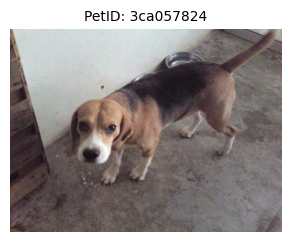


PetID: bed78eb25
AdoptionSpeed: 2
Description: please give this little girl a home. she definitely brings you laughters everyday with her unexpected cuteness! she is growing up so well and fat now


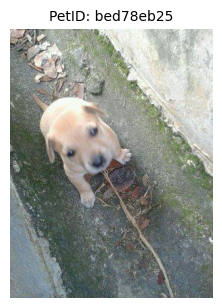


PetID: 91d230036
AdoptionSpeed: 1
Description: hello, her name is mowie. i found her at shell putra heights when she was meowing out loudly searching for foods & clean water. i think she lost her mom, i was so upset looking at this cute little kit...


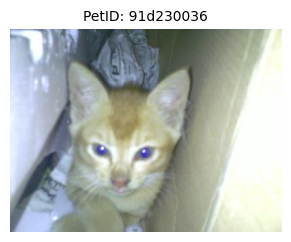


PetID: f17d4ab32
AdoptionSpeed: 4
Description: chiko is a loud and adorable kitten. she already toilet0trained and still learning to eat kibble. prefer to be adopted in pairs. (with   jessy) please take note: rm is imposed as a safe deposit which ...


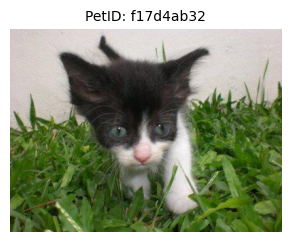


PetID: c71d537da
AdoptionSpeed: 2
Description: dear all, we found these two adorable puppies wandering at our neighborhood. we are looking for people who could adopt them urgently or else, these babies will be sent to the shelter home. they are va...


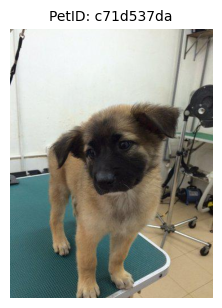

In [16]:
def show_random_examples(df, img_dir, n=5):
    """Display n random examples with image, description, adoption speed, and sentiment."""
    sample = df.sample(n)
    for idx, row in sample.iterrows():
        pet_id = row["PetID"]
        description = row["Description"]
        adoption_speed = row["AdoptionSpeed"] if "AdoptionSpeed" in row else "N/A"
        img_files = list(img_dir.glob(f"{pet_id}*.jpg"))
        print(f"\nPetID: {pet_id}")
        print(f"AdoptionSpeed: {adoption_speed}")
        print(
            f"Description: {description[:200]}{'...' if len(description) > 200 else ''}"
        )
        if img_files:
            img = Image.open(img_files[0]).convert("RGB")
            plt.figure(figsize=(3.5, 3.5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"PetID: {pet_id}", fontsize=10)
            plt.show()
        else:
            print("No image found.")


show_random_examples(train_df, IMG_TRAIN_DIR, n=5)

### Class balance

Class counts:
 AdoptionSpeed
1    1197
2    1773
3    1328
4    2133
Name: count, dtype: int64
Class distribution (%):
 AdoptionSpeed
1    18.61
2    27.57
3    20.65
4    33.17
Name: count, dtype: float64


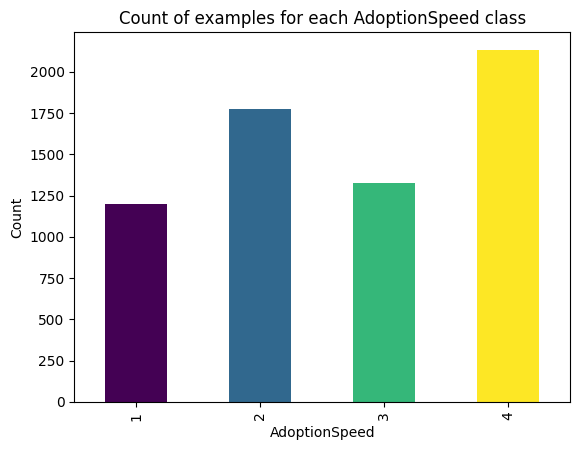

In [17]:
def plot_class_balance(df):
    """Plot the class balance of the AdoptionSpeed column."""
    counts = df["AdoptionSpeed"].value_counts().sort_index()
    print("Class counts:\n", counts)
    print("Class distribution (%):\n", (100 * counts / counts.sum()).round(2))
    counts.plot(kind="bar", color=plt.cm.viridis(np.linspace(0, 1, counts.size)))
    plt.xlabel("AdoptionSpeed")
    plt.ylabel("Count")
    plt.title("Count of examples for each AdoptionSpeed class")
    plt.show()


plot_class_balance(train_df)
# plot_class_balance(test_df)

## BERT Embeddings (Descriptions)

In [18]:
class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]


def fine_tune_last_layers(
    model,
    tokenizer,
    texts,
    labels,
    unfreeze_last_layers=2,
    num_epochs=1,
    batch_size=16,
    learning_rate=2e-5,
    device=DEVICE,
):

    for param in model.parameters():
        param.requires_grad = False

    if hasattr(model, "encoder") and hasattr(model.encoder, "layer"):
        encoder_layers = model.encoder.layer
        for layer in encoder_layers[-unfreeze_last_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    if hasattr(model, "pooler") and model.pooler is not None:
        for param in model.pooler.parameters():
            param.requires_grad = True

    model.to(device)
    model.train()

    dataset = SimpleTextDataset(texts, labels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    classifier = torch.nn.Linear(model.config.hidden_size, len(set(labels))).to(device)
    optimizer = torch.optim.AdamW(
        list(filter(lambda p: p.requires_grad, model.parameters()))
        + list(classifier.parameters()),
        lr=learning_rate,
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        for batch_texts, batch_labels in dataloader:
            inputs = tokenizer(
                batch_texts, padding=True, truncation=True, return_tensors="pt"
            ).to(device)
            batch_labels = batch_labels.to(device)
            outputs = model(**inputs)
            emb = outputs.last_hidden_state[:, 0, :]  # [CLS] embedding
            logits = classifier(emb)
            loss = loss_fn(logits, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{num_epochs}: loss = {loss.item():.4f}")
    model.eval()
    return model


def load_model_and_tokenizer(model_name="roberta-base", texts=None, unfreeze_last_layers=0, labels=None, fine_tune_epochs=1, fine_tune_bs=16, fine_tune_lr=2e-5, device=DEVICE):
    """Load a pre-trained model"""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)

    if unfreeze_last_layers > 0 and labels is not None:
        model = fine_tune_last_layers(
            model,
            tokenizer,
            texts,
            labels,
            unfreeze_last_layers=unfreeze_last_layers,
            num_epochs=fine_tune_epochs,
            batch_size=fine_tune_bs,
            learning_rate=fine_tune_lr,
            device=device,
        )

    model.eval()
    return model, tokenizer


def get_bert_embeddings(texts, split, model, model_name, tokenizer, batch_size=64, device=DEVICE):
    """Return array (n_samples, hidden_size)"""
    embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"{model_name} embedding"):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch.tolist(), padding=True, truncation=True, return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            output = model(**inputs)
            emb = (output.last_hidden_state.mean(dim=1).cpu().numpy())
        embs.append(emb)

    embs = np.concatenate(embs, axis=0)
    np.save(OUTPUTS / f"desc_bert_{split}.npy", embs)
    print(f"BERT {split} shape:", embs.shape)
    return embs

In [19]:
clean_gpu_resources()

MODEL_NAME = "roberta-base"
EMB_FINE_TUNE = True

model, tokenizer = None, None
if EMB_FINE_TUNE:
    mask = train_df["Description"].notnull()
    texts = train_df.loc[mask, "Description"]
    labels = train_df.loc[mask, "AdoptionSpeed"].astype(int)
    labels = labels - labels.min()
    model, tokenizer = load_model_and_tokenizer(
        model_name=MODEL_NAME,
        texts=texts,
        unfreeze_last_layers=1,
        labels=labels.values,
        fine_tune_epochs=5,
        fine_tune_bs=16,
        fine_tune_lr=2e-5,
        device=DEVICE,
    )
else:
    model, tokenizer = load_model_and_tokenizer(model_name=MODEL_NAME)

GPU memory cleared. Available: 7.6GB
Garbage collection completed


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5: loss = 1.3539
Epoch 2/5: loss = 1.2730
Epoch 3/5: loss = 1.2873
Epoch 4/5: loss = 1.2119
Epoch 5/5: loss = 1.0370


In [20]:
if not (OUTPUTS / "desc_bert_train.npy").exists() or not (OUTPUTS / "desc_bert_test.npy").exists():
    get_bert_embeddings(train_df["Description"], "train", model, MODEL_NAME, tokenizer)
    get_bert_embeddings(test_df["Description"], "test", model, MODEL_NAME, tokenizer)

roberta-base embedding: 100%|██████████| 101/101 [01:38<00:00,  1.03it/s]


BERT train shape: (6431, 768)


roberta-base embedding: 100%|██████████| 30/30 [00:27<00:00,  1.10it/s]

BERT test shape: (1891, 768)


## CLIP Embeddings (Images, first image of each PetID)

In [21]:
def clip_collate(batch):
    """Custom collate function for CLIP image dataset."""
    imgs, labels = zip(*batch)
    return list(imgs), torch.tensor(labels)


class CLIPImageDataset(Dataset):
    def __init__(self, img_dir, df, labels, processor, img_col="PetID", img_size=224):
        self.img_dir = Path(img_dir)
        self.pet_ids = list(df[img_col])
        self.labels = list(labels)
        self.processor = processor
        self.img_size = img_size

    def __len__(self):
        return len(self.pet_ids)

    def __getitem__(self, idx):
        pet_id = self.pet_ids[idx]
        img_files = list(self.img_dir.glob(f"{pet_id}*.jpg"))
        if not img_files:
            img = Image.new("RGB", (self.img_size, self.img_size), color=0)
        else:
            img = (
                Image.open(img_files[0])
                .convert("RGB")
                .resize((self.img_size, self.img_size))
            )

        inputs = self.processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)
        label = self.labels[idx]
        return pixel_values, label


def fine_tune_last_layers_clip(
    model,
    processor,
    img_dir,
    df,
    labels,
    unfreeze_last_layers=2,
    num_epochs=1,
    batch_size=16,
    learning_rate=2e-5,
    img_size=224,
    device=DEVICE,
):
    """Fine-tune the last layers of a CLIP model on image data."""

    # Freeze all params, then unfreeze last N layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last N visual transformer blocks
    if hasattr(model.vision_model.encoder, "layers"):
        layers = model.vision_model.encoder.layers
        for layer in layers[-unfreeze_last_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Unfreeze post_layernorm and projection
    for param in model.vision_model.post_layernorm.parameters():
        param.requires_grad = True
    for param in model.visual_projection.parameters():
        param.requires_grad = True

    model.to(device)
    model.train()

    dataset = CLIPImageDataset(img_dir, df, labels, processor=processor,img_size=img_size)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        collate_fn=clip_collate,
    )

    classifier = torch.nn.Linear(model.config.projection_dim, len(set(labels))).to(
        device
    )
    optimizer = torch.optim.AdamW(
        list(filter(lambda p: p.requires_grad, model.parameters()))
        + list(classifier.parameters()),
        lr=learning_rate,
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        for batch_imgs, batch_labels in dataloader:
            pixel_values = torch.stack(batch_imgs).to(device)
            batch_labels = batch_labels.to(device).long()

            with torch.no_grad():
                image_features = model.get_image_features(pixel_values=pixel_values)

            logits = classifier(image_features)
            loss = loss_fn(logits, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{num_epochs}: loss = {loss.item():.4f}")

    model.eval()
    return model, classifier

def get_clip_embeddings(img_dir, df, split, model, processor, batch_size=64, img_size=224, device=DEVICE):
    model.eval()
    dataset = CLIPImageDataset(img_dir, df, labels=[0] * len(df), processor=processor, img_size=img_size)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        collate_fn=clip_collate,
    )
    embs = []
    for batch_imgs, _ in tqdm(dataloader, desc=f"CLIP {split} embedding"):
        pixel_values = torch.stack(batch_imgs).to(device)
        with torch.no_grad():
            image_features = model.get_image_features(pixel_values=pixel_values)
        embs.append(image_features.cpu().numpy())
    embs = np.vstack(embs)
    np.save(OUTPUTS / f"clip_{split}.npy", embs)
    print(f"CLIP {split} shape:", embs.shape)
    return embs


def load_clip_model_and_processor(
    model_name="openai/clip-vit-base-patch32",
    img_dir=None,
    df=None,
    labels=None,
    unfreeze_last_layers=0,
    fine_tune_epochs=1,
    fine_tune_bs=16,
    fine_tune_lr=2e-5,
    img_size=224,
    device=DEVICE,
):
    processor = CLIPProcessor.from_pretrained(model_name)
    model = CLIPModel.from_pretrained(model_name).to(device)

    if unfreeze_last_layers > 0 and labels is not None and df is not None:
        model, classifier = fine_tune_last_layers_clip(
            model,
            processor,
            img_dir,
            df,
            labels,
            unfreeze_last_layers=unfreeze_last_layers,
            num_epochs=fine_tune_epochs,
            batch_size=fine_tune_bs,
            learning_rate=fine_tune_lr,
            img_size=img_size,
            device=device,
        )
    else:
        classifier = None
    model.eval()
    return model, processor, classifier

In [22]:
clean_gpu_resources()

MODEL_NAME = "openai/clip-vit-base-patch32"
IMG_SIZE = 224
CLIP_FINE_TUNE = True

if CLIP_FINE_TUNE:
    labels = train_df["AdoptionSpeed"].astype(int)
    labels = labels - labels.min()
    model, processor, classifier = load_clip_model_and_processor(
        model_name=MODEL_NAME,
        img_dir=IMG_TRAIN_DIR,
        df=train_df,
        labels=labels.values,
        unfreeze_last_layers=1,
        fine_tune_epochs=5,
        fine_tune_bs=16,
        fine_tune_lr=2e-5,
        img_size=IMG_SIZE,
    )
else:
    model, processor, classifier = load_clip_model_and_processor(
        model_name=MODEL_NAME,
        img_dir=None,
        df=None,
        labels=None,
        unfreeze_last_layers=0,
    )


if (
    not (OUTPUTS / "clip_train.npy").exists()
    or not (OUTPUTS / "clip_test.npy").exists()
):
    get_clip_embeddings(
        IMG_TRAIN_DIR,
        train_df,
        "train",
        model,
        processor,
        batch_size=64,
        img_size=IMG_SIZE,
    )
    get_clip_embeddings(
        IMG_TEST_DIR,
        test_df,
        "test",
        model,
        processor,
        batch_size=64,
        img_size=IMG_SIZE,
    )

GPU memory cleared. Available: 7.6GB


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Garbage collection completed


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 1/5: loss = 1.3839


...

Epoch 5/5: loss = 1.1459


CLIP train embedding:   0%|          | 0/101 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
CLIP train embedding: 100%|██████████| 101/101 [00:35<00:00,  2.84it/s]


CLIP train shape: (6431, 512)


CLIP test embedding:   0%|          | 0/30 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
CLIP test embedding: 100%|██████████| 30/30 [00:05<00:00,  5.47it/s]

CLIP test shape: (1891, 512)


## Feature Engineering (Mean/Cat Encoding + Tabular + Embeddings)

In [23]:
cat_features = [
    "has_image",
]
for col in cat_features:
    le = LabelEncoder()
    vals = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(vals.fillna("NA").astype(str))
    train_df[col + "_le"] = le.transform(train_df[col].fillna("NA").astype(str))
    test_df[col + "_le"] = le.transform(test_df[col].fillna("NA").astype(str))


tab_features = [
    "desc_length",
    "desc_word_count",
    "desc_unique_words",
    "desc_words_vs_unique",
    "desc_capitals",
    "desc_caps_vs_length",
    "desc_num_exclamation_marks",
    "desc_num_question_marks",
    "desc_num_punctuation",
    "desc_num_symbols",
    "desc_num_smilies",
    "desc_num_sad",
    "Description_stopword_count",
    "Description_stopword_ratio",
]

tab_features += [c + "_le" for c in cat_features]
display(tab_features)

bert_train = np.load(OUTPUTS / "desc_bert_train.npy")
bert_test = np.load(OUTPUTS / "desc_bert_test.npy")
clip_train = np.load(OUTPUTS / "clip_train.npy")
clip_test = np.load(OUTPUTS / "clip_test.npy")

X_tab = np.hstack([train_df[tab_features].values, bert_train, clip_train])
X_test_tab = np.hstack([test_df[tab_features].values, bert_test, clip_test])
y = train_df["AdoptionSpeed"].values


sample_weight = compute_sample_weight(class_weight="balanced", y=y)

['desc_length',
 'desc_word_count',
 'desc_unique_words',
 'desc_words_vs_unique',
 'desc_capitals',
 'desc_caps_vs_length',
 'desc_num_exclamation_marks',
 'desc_num_question_marks',
 'desc_num_punctuation',
 'desc_num_symbols',
 'desc_num_smilies',
 'desc_num_sad',
 'Description_stopword_count',
 'Description_stopword_ratio',
 'has_image_le']

## Optuna Hyperparameter Tuning (LightGBM)

In [24]:
def objective_lgbm(trial):
    """Objective function for LightGBM hyperparameter optimization."""
    params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": 400,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 24, 128),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "random_state": 42,
        "verbosity": -1,
    }

    # Add GPU acceleration if available
    if GPU_INFO.get('lightgbm', False):
        params['device'] = 'gpu'
        print("Using GPU acceleration for LightGBM optimization")
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    preds = np.zeros_like(y, dtype=float)
    for tr_idx, val_idx in cv.split(X_tab, y):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tab[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
        preds[val_idx] = model.predict(X_tab[val_idx])
    round_preds = np.clip(np.round(preds), 0, 4).astype(int)
    return -quadratic_weighted_kappa(y, round_preds)

clean_gpu_resources()
best_params = load_best_params(HYPERPARAMS_FILE)

if FORCE_REOPTIMIZE or best_params is None:
    print("No saved hyperparameters found or re-optimization forced.")
    study = optuna.create_study()
    study.optimize(objective_lgbm, n_trials=N_TRIALS)
    best_params = study.best_params

    # Check if GPU is available and update best_params accordingly
    if GPU_INFO.get('lightgbm', False):
        best_params['device'] = 'gpu'
        print("GPU acceleration added to best LightGBM parameters")
    else:
        print("Using CPU for LightGBM (GPU not available)")

    print("Best LightGBM params:", best_params)
    save_best_params(best_params, HYPERPARAMS_FILE)
else:
    print("Using saved hyperparameters from file.")

GPU memory cleared. Available: 7.6GB
Garbage collection completed


[I 2025-05-31 23:51:03,394] A new study created in memory with name: no-name-d1b378ff-0db7-420a-affa-a22698d7bfba


No saved hyperparameters found at /home/nickolasz/Projects/DataSets/GoIT/petfinder-final/outputs/lgbm_best_params.json
No saved hyperparameters found or re-optimization forced.
Using GPU acceleration for LightGBM optimization


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-05-31 23:53:12,609] Trial 0 finished with value: -0.3950097636295481 and parameters: {'learning_rate': 0.11596028553056702, 'num_leaves': 83, 'min_child_samples': 9, 'subsample': 0.9846427641686546, 'colsample_bytree': 0.608

Using GPU acceleration for LightGBM optimization


...

Using GPU acceleration for LightGBM optimization


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-06-01 00:35:01,003] Trial 23 finished with value: -0.41385326970311964 and parameters: {'learning_rate': 0.04431975922456631, 'num_leaves': 40, 'min_child_samples': 16, 'subsample': 0.6273985217083646, 'colsample_bytree': 0.

Using GPU acceleration for LightGBM optimization


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-06-01 00:36:22,330] Trial 24 finished with value: -0.41989410359068724 and parameters: {'learning_rate': 0.036244358839661206, 'num_leaves': 35, 'min_child_samples': 23, 'subsample': 0.711327096334519, 'colsample_bytree': 0.

GPU acceleration added to best LightGBM parameters
Best LightGBM params: {'learning_rate': 0.052990740018676416, 'num_leaves': 25, 'min_child_samples': 27, 'subsample': 0.5438685193239585, 'colsample_bytree': 0.9143575935294836, 'reg_alpha': 0.011220332156425, 'reg_lambda': 0.03463066206072572, 'device': 'gpu'}
Best hyperparameters saved to /home/nickolasz/Projects/DataSets/GoIT/petfinder-final/outputs/lgbm_best_params.json


## Training Models + Blending (LGBM, CatBoost, XGBoost)

In [25]:
def train_and_evaluate(X, y, X_test, sample_weight, best_params):
    """Train and evaluate LightGBM model with cross-validation."""
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    preds_test = np.zeros((len(X_test), folds.n_splits))
    
    # Ensure GPU parameters are included if available
    params_with_gpu = best_params.copy()
    if GPU_INFO.get('lightgbm', False) and 'device' not in params_with_gpu:
        params_with_gpu['device'] = 'gpu'
        print("Using GPU acceleration for LightGBM cross-validation")
    
    for i, (tr_idx, val_idx) in enumerate(folds.split(X, y)):
        try:
            model = lgb.LGBMRegressor(**params_with_gpu)
            model.fit(X[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
            oof[val_idx] = model.predict(X[val_idx])
            preds_test[:, i] = model.predict(X_test)
        except Exception as e:
            if 'device' in params_with_gpu and params_with_gpu['device'] == 'gpu':
                print(f"GPU training failed, falling back to CPU: {e}")
                params_with_gpu['device'] = 'cpu'
                model = lgb.LGBMRegressor(**params_with_gpu)
                model.fit(X[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
                oof[val_idx] = model.predict(X[val_idx])
                preds_test[:, i] = model.predict(X_test)
            else:
                raise e
    return oof, preds_test.mean(axis=1)


def train_catboost(X, y, X_test, sample_weight):
    """Train CatBoost model and return OOF and test predictions."""
    params = {
        "iterations": 400,
        "learning_rate": 0.04,
        "depth": 7,
        "random_seed": 42,
        "verbose": 0,
        "loss_function": "RMSE",
    }
    
    # Add GPU acceleration if available
    if GPU_INFO.get('catboost', False):
        params['task_type'] = 'GPU'
        print("Using GPU acceleration for CatBoost")
    
    try:
        model = CatBoostRegressor(**params)
        model.fit(X, y, sample_weight=sample_weight)
        return model.predict(X), model.predict(X_test)
    except Exception as e:
        if 'task_type' in params and params['task_type'] == 'GPU':
            print(f"CatBoost GPU training failed, falling back to CPU: {e}")
            params['task_type'] = 'CPU'
            model = CatBoostRegressor(**params)
            model.fit(X, y, sample_weight=sample_weight)
            return model.predict(X), model.predict(X_test)
        else:
            raise e


def train_xgboost(X, y, X_test, sample_weight):
    """Train XGBoost model and return OOF and test predictions."""
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 400,
        "learning_rate": 0.04,
        "max_depth": 7,
        "random_state": 42,
    }
    
    # Add GPU acceleration if available
    if GPU_INFO.get('xgboost', False):
        params['tree_method'] = 'gpu_hist'
        print("Using GPU acceleration for XGBoost")

    try:
        model = xgb.XGBRegressor(**params)
        model.fit(X, y, sample_weight=sample_weight)
        return model.predict(X), model.predict(X_test)
    except Exception as e:
        if 'tree_method' in params and params['tree_method'] == 'gpu_hist':
            print(f"XGBoost GPU training failed, falling back to CPU: {e}")
            params['tree_method'] = 'hist'
            model = xgb.XGBRegressor(**params)
            model.fit(X, y, sample_weight=sample_weight)
            return model.predict(X), model.predict(X_test)
        else:
            raise e

GPU memory cleared. Available: 7.6GB
Garbage collection completed


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature

Using GPU acceleration for CatBoost


Using GPU acceleration for XGBoost


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:37:00] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/xgboost/core.py:2676: UserWarning: [00:37:18] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/xgboost/core.py:729: UserWarning: [00:37

OOF QWK (blended): 0.7660588755509385


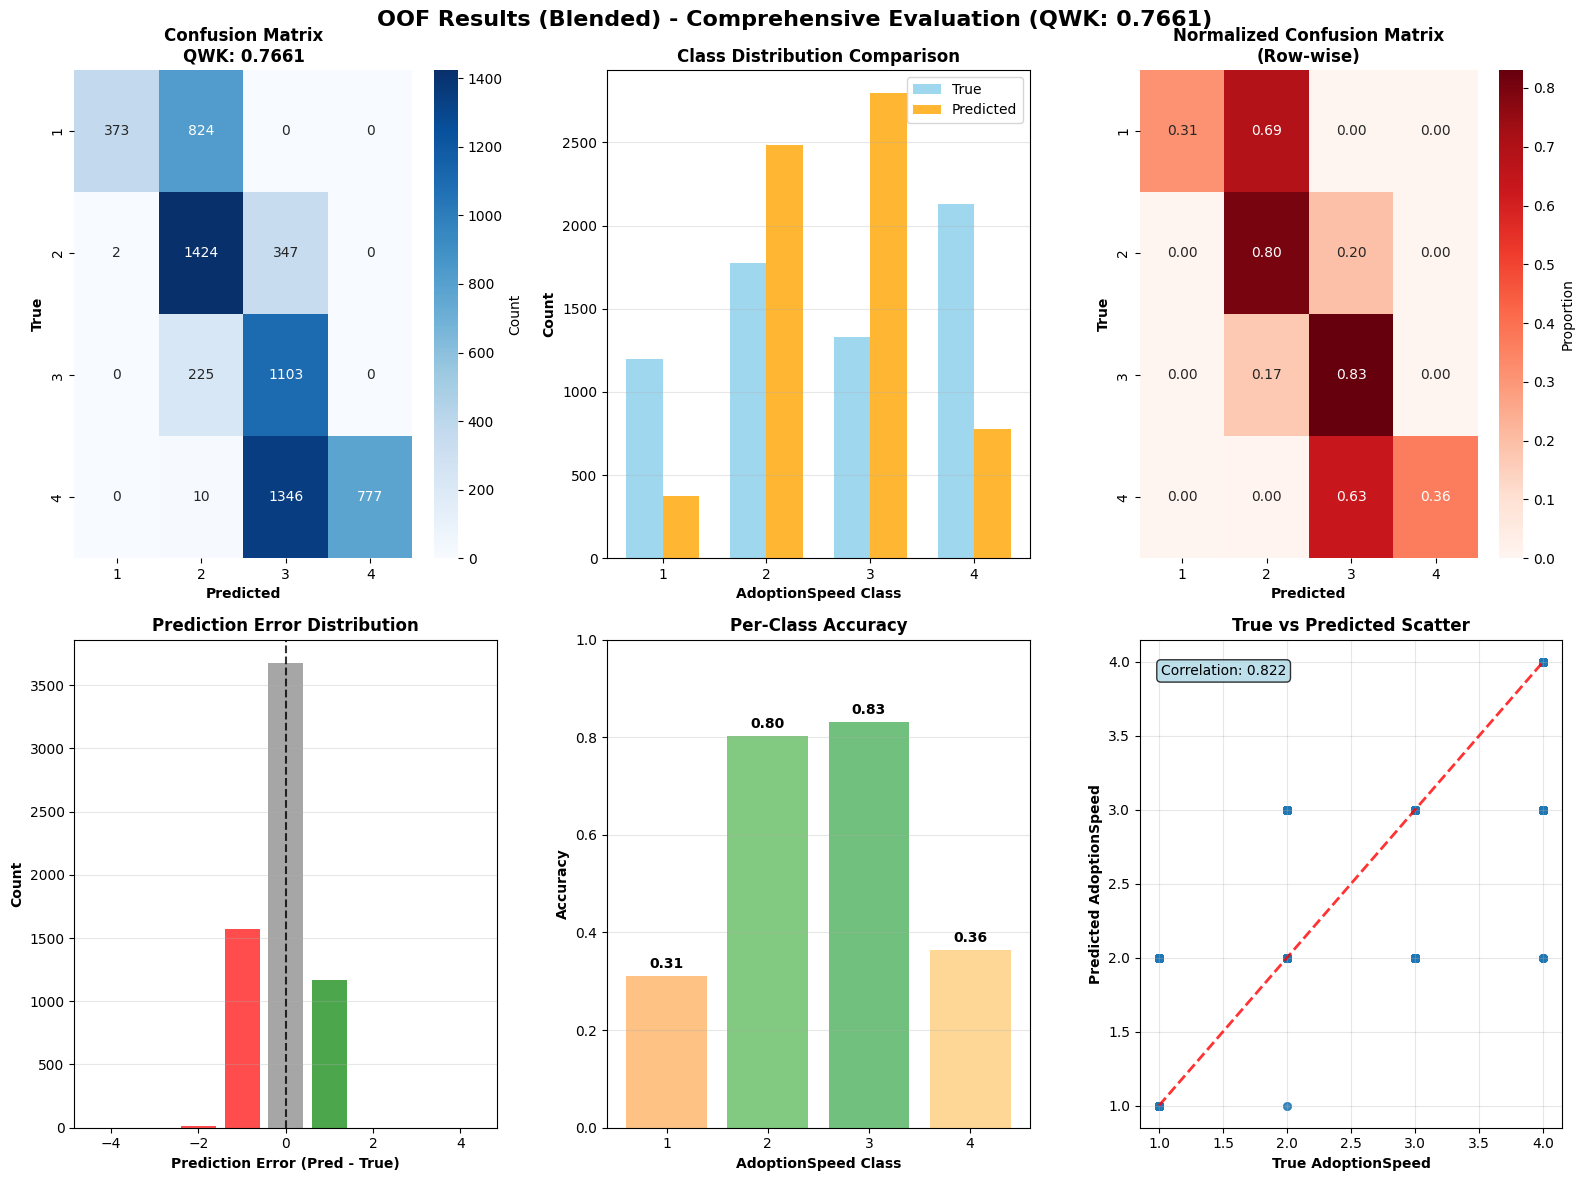

{'qwk': 0.7660588755509385,
 'confusion_matrix': array([[ 373,  824,    0,    0],
        [   2, 1424,  347,    0],
        [   0,  225, 1103,    0],
        [   0,   10, 1346,  777]]),
 'class_accuracies': [0.3116123642439432,
  0.8031584884376762,
  0.8305722891566265,
  0.36427566807313644],
 'correlation': 0.8217316589560651}

In [26]:
clean_gpu_resources()

oof_lgb, pred_lgb = train_and_evaluate(X_tab, y, X_test_tab, sample_weight, best_params)
oof_cat, pred_cat = train_catboost(X_tab, y, X_test_tab, sample_weight)
oof_xgb, pred_xgb = train_xgboost(X_tab, y, X_test_tab, sample_weight)

# Simple average stack
blended = (oof_lgb + oof_cat + oof_xgb) / 3
pred_blended = (pred_lgb + pred_cat + pred_xgb) / 3
round_preds = np.clip(np.round(blended), 0, 4).astype(int)
print("OOF QWK (blended):", quadratic_weighted_kappa(y, round_preds))
plot_detailed_results(y, round_preds, "OOF Results (Blended)")

## Final train and submission

In [27]:
def create_enhanced_weights(y, minority_classes=[3, 4], minority_factor=3.0):
    """Create weights with additional enhancement for minority classes"""

    balanced_weights = compute_sample_weight(class_weight="balanced", y=y)
    is_minority = np.isin(y, minority_classes)

    enhanced_weights = balanced_weights.copy()
    enhanced_weights[is_minority] *= minority_factor

    print(f"Mean weights for all classes: {balanced_weights.mean():.4f}")
    print(
        f"Mean weight for minority classes: {balanced_weights[is_minority].mean():.4f}"
    )
    print(
        f"Mean weight for minority classes (after enhancement): {enhanced_weights[is_minority].mean():.4f}"
    )

    return enhanced_weights


def create_enhanced_weights(y, minority_classes=[3, 4], minority_factor=3.0):
    """Create weights with additional enhancement for minority classes"""

    balanced_weights = compute_sample_weight(class_weight="balanced", y=y)
    is_minority = np.isin(y, minority_classes)

    enhanced_weights = balanced_weights.copy()
    enhanced_weights[is_minority] *= minority_factor

    print(f"Mean weights for all classes: {balanced_weights.mean():.4f}")
    print(
        f"Mean weight for minority classes: {balanced_weights[is_minority].mean():.4f}"
    )
    print(
        f"Mean weight for minority classes (after enhancement): {enhanced_weights[is_minority].mean():.4f}"
    )

    return enhanced_weights


def apply_smote_oversampling(X, y, sampling_strategy=None, random_state=42):
    """Apply SMOTE for oversampling minority classes"""

    if sampling_strategy is None:
        class_counts = np.bincount(y)
        max_count = class_counts.max()

        target_count = max_count // 2
        sampling_strategy = {}
        for cls, count in enumerate(class_counts):
            # Only add class to strategy if it exists (count > 0) and has fewer samples than max
            if count > 0 and count < max_count:
                sampling_strategy[cls] = min(max_count, max(target_count, count))

    # Verify that all classes in sampling_strategy exist in the data
    # This prevents the "target class is not present in the data" error
    present_classes = set(np.unique(y))
    sampling_strategy = {
        cls: count for cls, count in sampling_strategy.items() if cls in present_classes
    }

    class_counts_before = np.bincount(y)
    print("Distribution of classes before SMOTE:")
    for cls, count in enumerate(class_counts_before):
        print(f"Class {cls}: {count} samples ({100*count/len(y):.2f}%)")

    smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    class_counts_after = np.bincount(y_resampled)
    print("\nDistribution of classes after SMOTE:")
    for cls, count in enumerate(class_counts_after):
        print(f"Class {cls}: {count} samples ({100*count/len(y_resampled):.2f}%)")

    plt.figure(figsize=(10, 6))
    plt.bar(
        np.arange(len(class_counts_before)) - 0.2,
        class_counts_before,
        width=0.4,
        color="skyblue",
        label="Before SMOTE",
    )
    plt.bar(
        np.arange(len(class_counts_after)) + 0.2,
        class_counts_after,
        width=0.4,
        color="salmon",
        label="After SMOTE",
    )
    plt.xlabel("Class (AdoptionSpeed)", fontsize=12)
    plt.ylabel("Number of samples", fontsize=12)
    plt.title("Comparison of class distribution before and after SMOTE", fontsize=14)
    plt.xticks(np.arange(len(class_counts_before)), np.arange(len(class_counts_before)))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return X_resampled, y_resampled

In [28]:
class OptimizedRounder:
    """Find optimal rounding thresholds for regression to classes."""

    def __init__(self):
        self.coef_ = [0.5, 1.5, 2.5, 3.5]

    def _kappa_loss(self, coef, X, y):
        X_p = self.predict(X, coef)
        return -quadratic_weighted_kappa(y, X_p)

    def fit(self, X, y):
        from scipy.optimize import minimize

        loss_partial = lambda c: self._kappa_loss(c, X, y)
        initial_coef = self.coef_
        bounds = [(None, None)] * len(initial_coef)
        result = minimize(loss_partial, initial_coef, method="nelder-mead")
        self.coef_ = result.x

    def predict(self, X, coef=None):
        if coef is None:
            coef = self.coef_
        coef = np.sort(coef)
        X_p = np.digitize(X, coef)
        return X_p

    def coefficients(self):
        return self.coef_

GPU memory cleared. Available: 7.6GB
Garbage collection completed
Using enhanced weights for final model...
Mean weights for all classes: 1.0000
Mean weight for minority classes: 0.9291
Mean weight for minority classes (after enhancement): 4.6453
Train final model LightGBM...


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ LightGBM final model trained with GPU acceleration
Train final model CatBoost...


CatBoost final model trained with GPU acceleration
Train final model XGBoost...


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:37:32] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/xgboost/core.py:2676: UserWarning: [00:37:48] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWa

XGBoost final model trained with GPU acceleration
FINAL QWK (train, blended): 0.8041


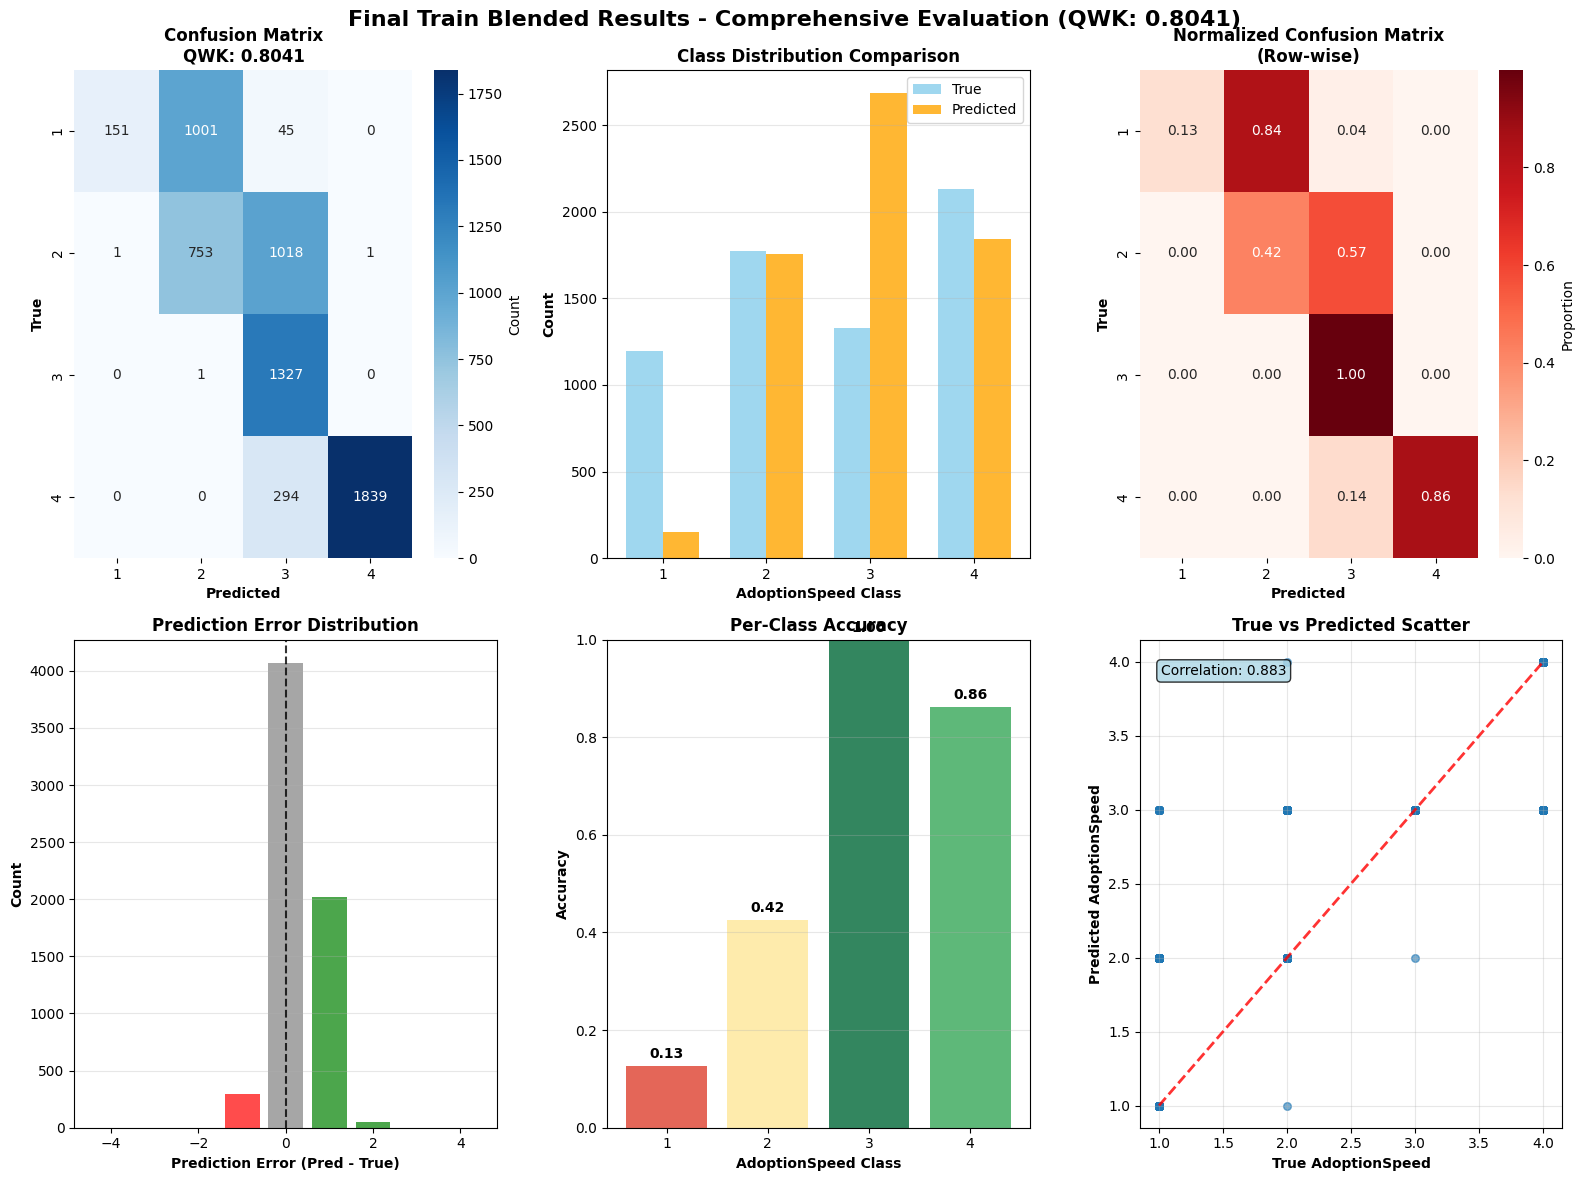

FINAL submission saved!


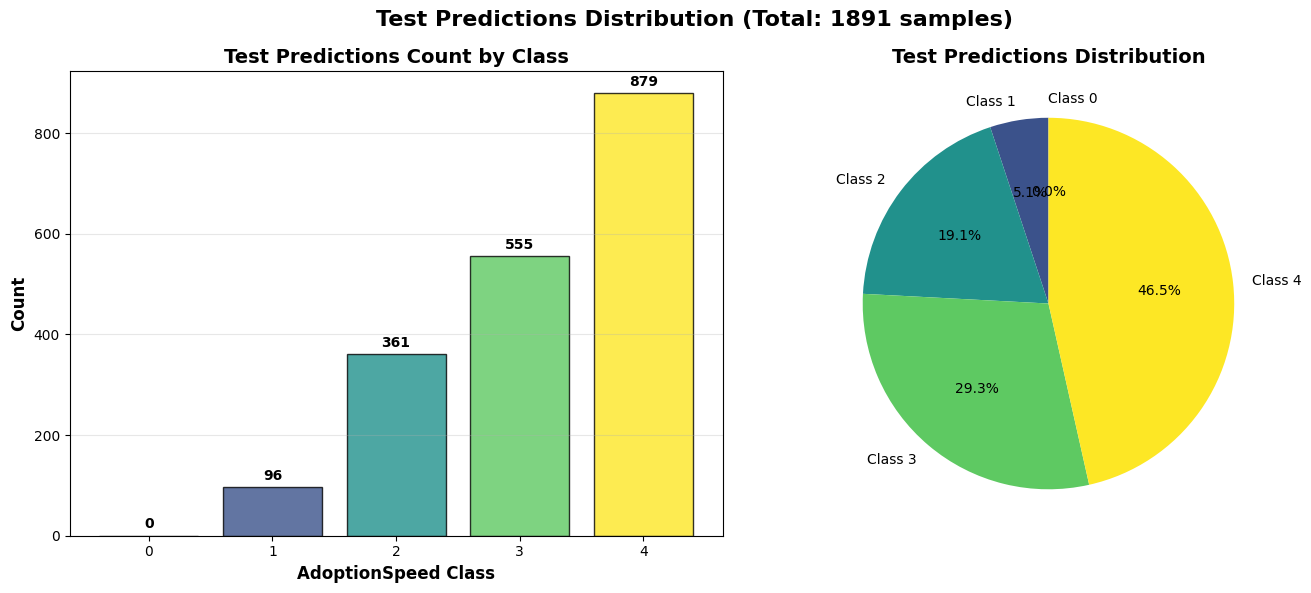


=== Test Predictions Distribution Summary ===
Total samples: 1891
Class 0:    0 (  0.0%)
Class 1:   96 (  5.1%)
Class 2:  361 ( 19.1%)
Class 3:  555 ( 29.3%)
Class 4:  879 ( 46.5%)


In [29]:
# True for enhanced weights, False for standard weights
clean_gpu_resources()

use_enhanced_weights = True
use_smote = False
class_counts = np.bincount(y)

if use_smote:
    print("Using SMOTE for oversampling...")
    X_final_train, y_final_train = apply_smote_oversampling(
        X_tab, y, 
        sampling_strategy={
            cls: max(count, class_counts.max() // 2) 
            for cls, count in enumerate(class_counts)
            if count < class_counts.max()
        }
    )
else:
    X_final_train, y_final_train = X_tab, y

# Prepare final weights
if use_enhanced_weights:
    print("Using enhanced weights for final model...")
    final_weights = create_enhanced_weights(y_final_train, minority_classes=[3, 4], minority_factor=5.0)
else:
    if use_smote:
        final_weights = np.ones(len(y_final_train))
    else:
        final_weights = sample_weight


print("Train final model LightGBM...")
# Ensure GPU parameters are included if available
final_lgb_params = best_params.copy()
if GPU_INFO.get('lightgbm', False) and 'device' not in final_lgb_params:
    final_lgb_params['device'] = 'gpu'

try:
    lgb_final = lgb.LGBMRegressor(**final_lgb_params)
    lgb_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
    lgb_pred_test = lgb_final.predict(X_test_tab)
    if 'device' in final_lgb_params and final_lgb_params['device'] == 'gpu':
        print("✓ LightGBM final model trained with GPU acceleration")
except Exception as e:
    if 'device' in final_lgb_params and final_lgb_params['device'] == 'gpu':
        print(f"LightGBM GPU training failed, falling back to CPU: {e}")
        final_lgb_params['device'] = 'cpu'
        lgb_final = lgb.LGBMRegressor(**final_lgb_params)
        lgb_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
        lgb_pred_test = lgb_final.predict(X_test_tab)
    else:
        raise e

print("Train final model CatBoost...")
final_cat_params = {
    "iterations": 400,
    "learning_rate": 0.04,
    "depth": 7,
    "random_seed": 42,
    "verbose": 0,
    "loss_function": "RMSE",
}

# Add GPU acceleration if available
if GPU_INFO.get('catboost', False):
    final_cat_params['task_type'] = 'GPU'

try:
    cat_final = CatBoostRegressor(**final_cat_params)
    cat_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
    cat_pred_test = cat_final.predict(X_test_tab)
    if 'task_type' in final_cat_params and final_cat_params['task_type'] == 'GPU':
        print("CatBoost final model trained with GPU acceleration")
except Exception as e:
    if 'task_type' in final_cat_params and final_cat_params['task_type'] == 'GPU':
        print(f"CatBoost GPU training failed, falling back to CPU: {e}")
        final_cat_params['task_type'] = 'CPU'
        cat_final = CatBoostRegressor(**final_cat_params)
        cat_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
        cat_pred_test = cat_final.predict(X_test_tab)
    else:
        raise e

print("Train final model XGBoost...")
final_xgb_params = {
    "objective": "reg:squarederror",
    "n_estimators": 400,
    "learning_rate": 0.04,
    "max_depth": 7,
    "random_state": 42,
}

# Add GPU acceleration if available
if GPU_INFO.get('xgboost', False):
    final_xgb_params['tree_method'] = 'gpu_hist'

try:
    xgb_final = xgb.XGBRegressor(**final_xgb_params)
    xgb_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
    xgb_pred_test = xgb_final.predict(X_test_tab)
    if 'tree_method' in final_xgb_params and final_xgb_params['tree_method'] == 'gpu_hist':
        print("XGBoost final model trained with GPU acceleration")
except Exception as e:
    if 'tree_method' in final_xgb_params and final_xgb_params['tree_method'] == 'gpu_hist':
        print(f"XGBoost GPU training failed, falling back to CPU: {e}")
        final_xgb_params['tree_method'] = 'hist'
        xgb_final = xgb.XGBRegressor(**final_xgb_params)
        xgb_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
        xgb_pred_test = xgb_final.predict(X_test_tab)
    else:
        raise e

lgb_pred_train = lgb_final.predict(X_tab)
cat_pred_train = cat_final.predict(X_tab)
xgb_pred_train = xgb_final.predict(X_tab)
pred_blended_train = (lgb_pred_train + cat_pred_train + xgb_pred_train) / 3
round_blended_train = np.clip(np.round(pred_blended_train), 0, 4).astype(int)
qwk_final = quadratic_weighted_kappa(y, round_blended_train)
print(f"FINAL QWK (train, blended): {qwk_final:.4f}")
plot_detailed_results(y, round_blended_train, "Final Train Blended Results")

optR = OptimizedRounder()
optR.fit(blended, y)  # blended = (oof_lgb + oof_cat + oof_xgb) / 3
best_coef = optR.coefficients()

pred_blended_final = (lgb_pred_test + cat_pred_test + xgb_pred_test) / 3
final_preds = optR.predict(pred_blended_final, best_coef)
final_preds = np.clip(final_preds, 0, 4).astype(int)

submission = pd.DataFrame(
    {
        "PetID": test_df["PetID"],
        "AdoptionSpeed": final_preds,
    }
)

# Kaggle result: ___
submission.to_csv(OUTPUTS / "submission.csv", index=False)
print("FINAL submission saved!")
plot_test_predictions_distribution(submission["AdoptionSpeed"].values)

Minority Class Report:
3    2449
4     777
2     235
Name: count, dtype: int64


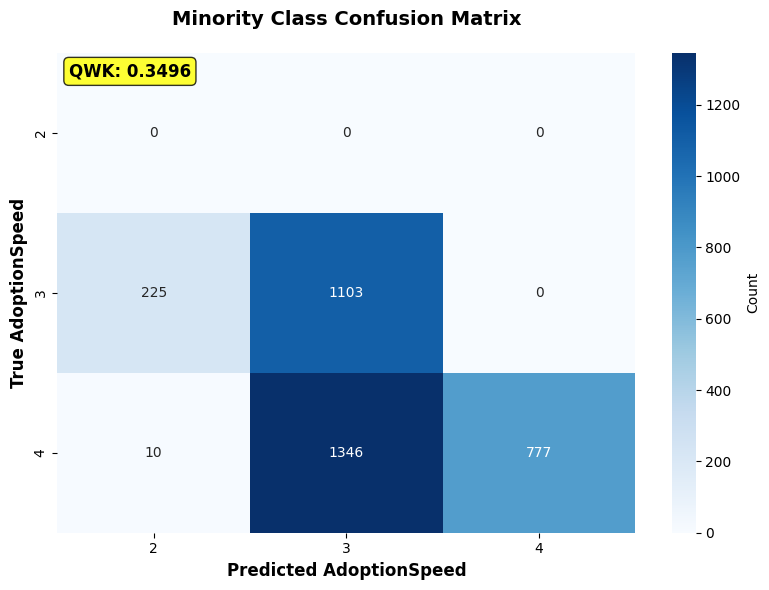

In [30]:
def analyze_minority_class(y_true, y_pred, minority_classes=[3, 4]):
    """Analyze and visualize results for minority classes."""
    mask = np.isin(y_true, minority_classes)
    print("Minority Class Report:")
    print(pd.Series(y_pred[mask]).value_counts())
    plot_confusion_matrix(
        y_true[mask], y_pred[mask], title="Minority Class Confusion Matrix"
    )


analyze_minority_class(y, round_preds)

## Impruve handling of minority classes

Mean weights for all classes: 1.0000
Mean weight for minority classes: 0.9291
Mean weight for minority classes (after enhancement): 4.6453
Sampling strategy: {1: 1197, 2: 1773, 3: 1328}
Distribution of classes before SMOTE:
Class 0: 0 samples (0.00%)
Class 1: 1197 samples (18.61%)
Class 2: 1773 samples (27.57%)
Class 3: 1328 samples (20.65%)
Class 4: 2133 samples (33.17%)

Distribution of classes after SMOTE:
Class 0: 0 samples (0.00%)
Class 1: 1197 samples (18.61%)
Class 2: 1773 samples (27.57%)
Class 3: 1328 samples (20.65%)
Class 4: 2133 samples (33.17%)


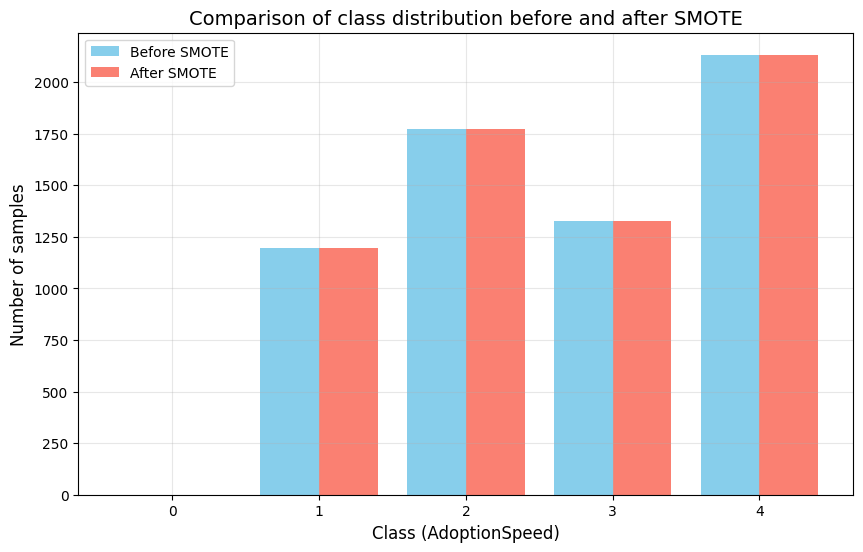


=== Train models with enhanced weights (without SMOTE) ===
QWK with enhanced weights: 0.6166
Minority Class Report:
3    2086
4    1366
2       9
Name: count, dtype: int64


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


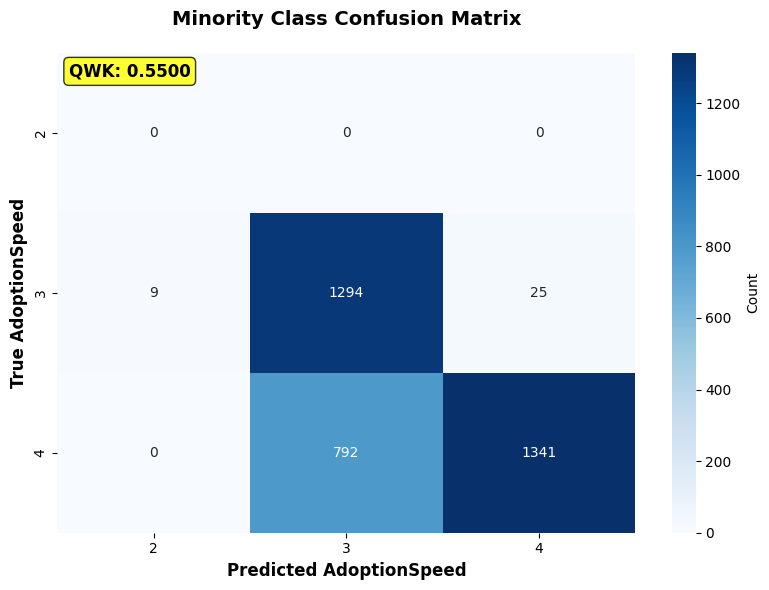


=== Train models on data with SMOTE ===
QWK with SMOTE: 0.6938
Minority Class Report:
3    2282
4     846
2     333
Name: count, dtype: int64


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


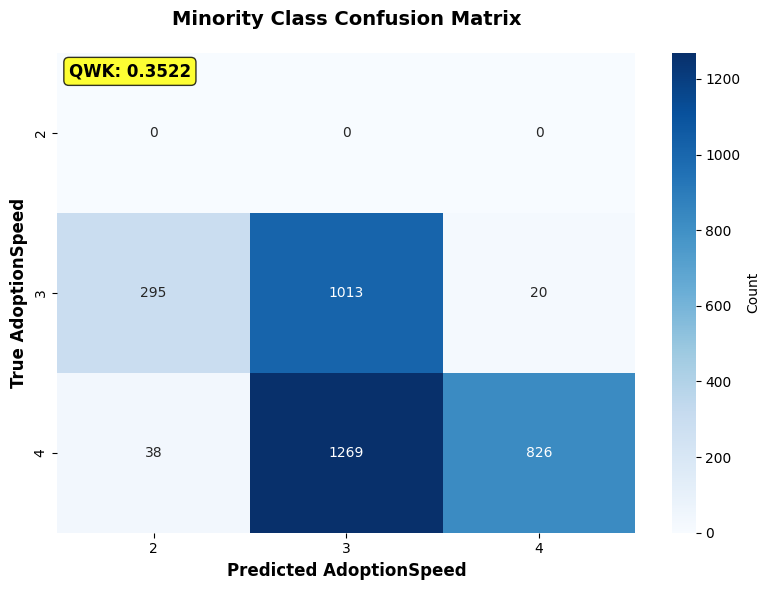


=== Train models on data with SMOTE and enhanced weights ===
Mean weights for all classes: 1.0000
Mean weight for minority classes: 0.9291
Mean weight for minority classes (after enhancement): 1.8581
QWK with SMOTE and enhanced weights: 0.6702
Minority Class Report:
3    2500
4     827
2     134
Name: count, dtype: int64


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


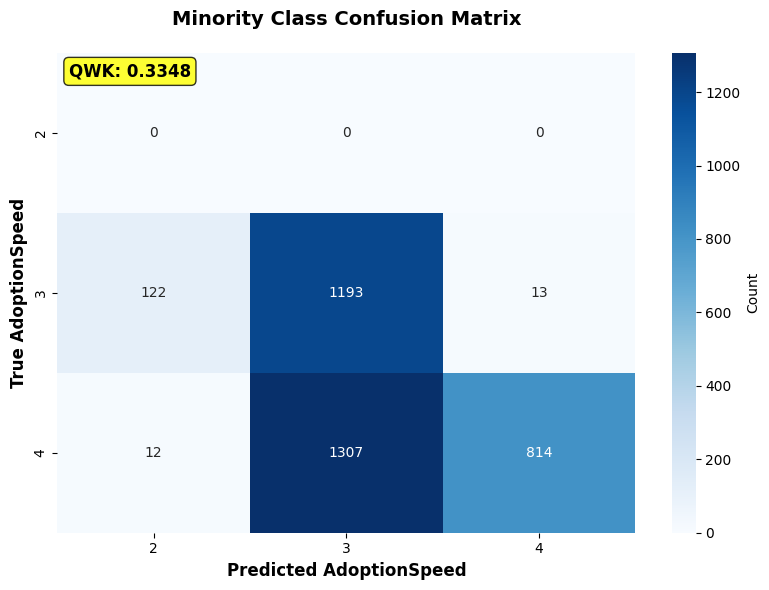


=== Comparison table of QWK for minority classes ===
                     Method  QWK (overall)  QWK (Minority Class)
0                Base model       0.766059              0.349599
1          Enhanced weights       0.616632              0.549955
2                     SMOTE       0.693832              0.352162
3  SMOTE + enhanced weights       0.670242              0.334766

Best method for minority classes: Enhanced weights


In [31]:
# Create enhanced weights for minority classes
enhanced_weights = create_enhanced_weights(y, minority_classes=[3, 4], minority_factor=5.0)

# Apply SMOTE to create synthetic examples
# Define the oversampling strategy - increase the underrepresented classes
class_counts = np.bincount(y)
max_count = class_counts.max() // 2  # Target count - half of the maximum class

sampling_strategy = {}
for cls, count in enumerate(class_counts):
    # Only add class to strategy if it exists (count > 0) and has fewer samples than the maximum class
    if count > 0 and count < class_counts.max():
        sampling_strategy[cls] = max(count, max_count)

print("Sampling strategy:", sampling_strategy)

# Apply SMOTE only to the training data, not to the test data
X_smote, y_smote = apply_smote_oversampling(X_tab, y, sampling_strategy=sampling_strategy)

# Train models with enhanced weights (without SMOTE)
print("\n=== Train models with enhanced weights (without SMOTE) ===")
lgb_enhanced = lgb.LGBMRegressor(**best_params)
lgb_enhanced.fit(X_tab, y, sample_weight=enhanced_weights)
lgb_pred_enhanced = lgb_enhanced.predict(X_tab)
round_preds_enhanced = np.clip(np.round(lgb_pred_enhanced), 0, 4).astype(int)
qwk_enhanced = quadratic_weighted_kappa(y, round_preds_enhanced)
print(f"QWK with enhanced weights: {qwk_enhanced:.4f}")
analyze_minority_class(y, round_preds_enhanced)

# Train models on data with SMOTE
print("\n=== Train models on data with SMOTE ===")
lgb_smote = lgb.LGBMRegressor(**best_params)
lgb_smote.fit(X_smote, y_smote)  # No additional weights needed here since SMOTE has balanced the classes
lgb_pred_smote = lgb_smote.predict(X_tab)
round_preds_smote = np.clip(np.round(lgb_pred_smote), 0, 4).astype(int)
qwk_smote = quadratic_weighted_kappa(y, round_preds_smote)
print(f"QWK with SMOTE: {qwk_smote:.4f}")
analyze_minority_class(y, round_preds_smote)

# Train models on data with SMOTE and enhanced weights
print("\n=== Train models on data with SMOTE and enhanced weights ===")
smote_weights = create_enhanced_weights(y_smote, minority_classes=[3, 4], minority_factor=2.0)
lgb_combined = lgb.LGBMRegressor(**best_params)
lgb_combined.fit(X_smote, y_smote, sample_weight=smote_weights)
lgb_pred_combined = lgb_combined.predict(X_tab)
round_preds_combined = np.clip(np.round(lgb_pred_combined), 0, 4).astype(int)
qwk_combined = quadratic_weighted_kappa(y, round_preds_combined)
print(f"QWK with SMOTE and enhanced weights: {qwk_combined:.4f}")
analyze_minority_class(y, round_preds_combined)

# Comparison of results for minority classes
minority_mask = np.isin(y, [3, 4])
print("\n=== Comparison table of QWK for minority classes ===")
methods = ["Base model", "Enhanced weights", "SMOTE", "SMOTE + enhanced weights"]
qwks = [
    quadratic_weighted_kappa(y[minority_mask], round_preds[minority_mask]),
    quadratic_weighted_kappa(y[minority_mask], round_preds_enhanced[minority_mask]),
    quadratic_weighted_kappa(y[minority_mask], round_preds_smote[minority_mask]),
    quadratic_weighted_kappa(y[minority_mask], round_preds_combined[minority_mask])
]

comparison_df = pd.DataFrame(
    {
        "Method": methods,
        "QWK (overall)": [
            quadratic_weighted_kappa(y, round_preds),
            qwk_enhanced,
            qwk_smote,
            qwk_combined,
        ],
        "QWK (Minority Class)": qwks,
    }
)
print(comparison_df)

# Determine the best method for further fine-tuning the final model
best_method_idx = np.argmax(qwks)
best_method = methods[best_method_idx]
print(f"\nBest method for minority classes: {best_method}")